<a href="https://colab.research.google.com/github/logankim0913/EE_467_Final_Project/blob/main/phase_3_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Data
Loading data from the Benign/Dictionary Brute Force/DNS_Spoofing dataset. Since the CIC IoT Intrusion dataset for benign traffic comes with a number of batches of data, which we are using to train our autoencoder, we can simply designate some of them for training and the other for testing instead of spliting up a single dataset. This is done under the assumption that these benign traffic datasets are independent from each other; training the autoencoder with one of them should not "leak" any information about the test benign traffic dataset.

In [1]:
import pandas as pd
import gc

# scaling only on benign data
back_mal = pd.read_csv("Backdoor_Malware.pcap.csv")
benign = pd.read_csv("BenignTraffic.pcap.csv")
benign1 = pd.read_csv("BenignTraffic1.pcap.csv")
benign2 = pd.read_csv("BenignTraffic2.pcap.csv")
benign3 = pd.read_csv("BenignTraffic3.pcap.csv")

brow_hijack = pd.read_csv("BrowserHijacking.pcap.csv")
comm_inject = pd.read_csv("CommandInjection.pcap.csv")

spoof = pd.read_csv("DNS_Spoofing.pcap.csv")
bfd = pd.read_csv("DictionaryBruteForce.pcap.csv")

mitm_arp = pd.read_csv("MITM-ArpSpoofing.pcap.csv")

raw_mirai_greeth = pd.read_csv("Mirai-greeth_flood.pcap.csv")
raw_mirai_greip = pd.read_csv("Mirai-greip_flood.pcap.csv")
raw_mirai_udpplain = pd.read_csv("Mirai-udpplain.pcap.csv")

recon_host = pd.read_csv("Recon-HostDiscovery.pcap.csv")
recon_os = pd.read_csv("Recon-OSScan.pcap.csv")
recon_ping = pd.read_csv("Recon-PingSweep.pcap.csv")
recon_port = pd.read_csv("Recon-PortScan.pcap.csv")

sql_inject = pd.read_csv("SqlInjection.pcap.csv")
upload_attack = pd.read_csv("Uploading_Attack.pcap.csv")
vuln_scan = pd.read_csv("VulnerabilityScan.pcap.csv")
xss = pd.read_csv("XSS.pcap.csv")

# use different datasets for train/val/test benign
train_benign = pd.concat([benign, benign1])
val_benign = benign2
test_benign = benign3

# Establish the seed for any random_state functions later open
RANDOM_SEED = 42

## Sampling Strategy for DoS Samples
For phase 2, we are adding Mirai and DoS-TCP intrusion datasets for exposing the autoencoder to the messy, high-volume reality of IoT botnets. DoS-TCP dataset, especially, is potentially too large for memory to handle; we will implement a way to *chunk* the dataset instead loading the whole thing to RAM--it will ensure that RAM is not overoccupied. The goal is to sample the traffics that carry the most representative of the full dataset like the ones with peaks.

In [2]:
import pandas as pd
import numpy as np

def count_rows_csv(csv_path, chunksize=50000):
    total = 0
    for chunk in pd.read_csv(csv_path, chunksize=chunksize):
        total += len(chunk)
    return total

def clean_df(df):
    return df.replace([np.inf, -np.inf], np.nan).dropna()

# Returns a subset of the given dos dataset that best represents it
def sample_dos(
    csv_path,
    target_rows=100000,
    chunksize=50000,
    n_bins=10,
    peak_frac=0.01,
    priority_col="Time_To_Live",
    random_state=42
):
    total_rows = count_rows_csv(csv_path, chunksize=chunksize)
    sample_frac = min(1.0, target_rows / total_rows)
    kept = []
    start_idx = 0

    for chunk in pd.read_csv(csv_path, chunksize=chunksize):
        chunk = clean_df(chunk).copy()
        if len(chunk) == 0:
            continue

        global_idx = np.arange(start_idx, start_idx + len(chunk))
        chunk["bin"] = np.floor(global_idx / total_rows * n_bins).astype(int)
        chunk["bin"] = chunk["bin"].clip(0, n_bins - 1)
        start_idx += len(chunk)

        bin_parts = []
        for b in range(n_bins):
            part = chunk[chunk["bin"] == b]
            if len(part) == 0:
                continue

            # random sampling
            rand_n = max(1, int(len(part) * sample_frac))
            rand_part = part.sample(n=min(rand_n, len(part)), random_state=random_state)

            # 2. priority sampling (only if the priority column exists)
            if priority_col in part.columns:
                peak_n = max(1, int(len(part) * peak_frac))
                peak_part = part.nlargest(peak_n, priority_col)
                keep_part = pd.concat([rand_part, peak_part], ignore_index=True).drop_duplicates()
            else:
                keep_part = rand_part
            bin_parts.append(keep_part)

        if bin_parts:
            kept.append(pd.concat(bin_parts, ignore_index=True))

    dos_sampled = pd.concat(kept, ignore_index=True).drop_duplicates()
    return dos_sampled

Quick check to see if the sampling has reduced the size of the dataset to prevent overwhelmed RAM usage.

In [3]:
sampled_dos_tcp = sample_dos("DoS-TCP_Flood.pcap.csv")
sampled_dos_syn = sample_dos("DoS-SYN_Flood.pcap.csv")
sampled_dos_http = sample_dos("DoS-HTTP_Flood.pcap.csv")
sampled_dos_udp = sample_dos("DoS-UDP_Flood.pcap.csv")

print("raw_dos rows:", count_rows_csv("DoS-TCP_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_dos_tcp.shape)

print("raw_dos rows:", count_rows_csv("DoS-SYN_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_dos_syn.shape)

print("raw_dos rows:", count_rows_csv("DoS-HTTP_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_dos_http.shape)

print("raw_dos rows:", count_rows_csv("DoS-UDP_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_dos_udp.shape)

raw_dos rows: 260129
sampled_dos shape: (84227, 40)
raw_dos rows: 262691
sampled_dos shape: (100143, 40)
raw_dos rows: 40686
sampled_dos shape: (40682, 40)
raw_dos rows: 166838
sampled_dos shape: (94503, 40)


Utilize chunking on the DDoS datasets

In [4]:
sampled_ddos_ackfrag = sample_dos("DDoS-ACK_Fragmentation.pcap.csv")
sampled_ddos_http = sample_dos("DDoS-HTTP_Flood-.pcap.csv")
sampled_ddos_icmp = sample_dos("DDoS-ICMP_Flood.pcap.csv")
sampled_ddos_pshack = sample_dos("DDoS-PSHACK_Flood.pcap.csv")
sampled_ddos_rstfin = sample_dos("DDoS-RSTFINFlood.pcap.csv")
sampled_ddos_syn = sample_dos("DDoS-SYN_Flood.pcap.csv")
sampled_ddos_slowloris = sample_dos("DDoS-SlowLoris.pcap.csv")
sampled_ddos_synIP = sample_dos("DDoS-SynonymousIP_Flood.pcap.csv")
sampled_ddos_tcp = sample_dos("DDoS-TCP_Flood.pcap.csv")
sampled_ddos_udp = sample_dos("DDoS-UDP_Flood.pcap.csv")
sampled_ddos_udpfrag = sample_dos("DDoS-UDP_Fragmentation.pcap.csv")


print("raw_ddos rows:", count_rows_csv("DDoS-ACK_Fragmentation.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_ackfrag.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-HTTP_Flood-.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_http.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-ICMP_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_icmp.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-PSHACK_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_pshack.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-RSTFINFlood.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_rstfin.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-SYN_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_syn.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-SlowLoris.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_slowloris.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-SynonymousIP_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_synIP.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-TCP_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_tcp.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-UDP_Flood.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_udp.shape)

print("raw_ddos rows:", count_rows_csv("DDoS-UDP_Fragmentation.pcap.csv"))
print("sampled_dos shape:", sampled_ddos_udpfrag.shape)

raw_ddos rows: 25090
sampled_dos shape: (25089, 40)
raw_ddos rows: 28790
sampled_dos shape: (28790, 40)
raw_ddos rows: 268010
sampled_dos shape: (91253, 40)
raw_ddos rows: 267811
sampled_dos shape: (91570, 40)
raw_ddos rows: 266934
sampled_dos shape: (95455, 40)
raw_ddos rows: 266024
sampled_dos shape: (96009, 40)
raw_ddos rows: 23426
sampled_dos shape: (23425, 40)
raw_ddos rows: 268626
sampled_dos shape: (88688, 40)
raw_ddos rows: 265776
sampled_dos shape: (84490, 40)
raw_ddos rows: 266605
sampled_dos shape: (86252, 40)
raw_ddos rows: 22542
sampled_dos shape: (22536, 40)


## Preprocessing - Drop problematic features
Because we see that features like `Rate` has unprocessable values, we will remove that feature for preprocessing step later.

In [5]:
import numpy as np

# handle infinite values before scaling drop rows with infinity
back_mal = clean_df(back_mal)
bfd = clean_df(bfd)
spoof = clean_df(spoof)
benign_train = clean_df(train_benign.drop(columns=["Rate"]))
benign_val = clean_df(val_benign.drop(columns=["Rate"]))
benign_test = clean_df(test_benign.drop(columns=["Rate"]))
brow_hijack = clean_df(brow_hijack)
comm_inject = clean_df(comm_inject)
mitm_arp = clean_df(mitm_arp)
mirai_greeth = clean_df(raw_mirai_greeth)
mirai_greip = clean_df(raw_mirai_greip)
mirai_udpplain = clean_df(raw_mirai_udpplain)
recon_host = clean_df(recon_host)
recon_os = clean_df(recon_os)
recon_ping = clean_df(recon_ping)
recon_port = clean_df(recon_port)
sql_inject = clean_df(sql_inject)
upload_attack = clean_df(upload_attack)
vuln_scan = clean_df(vuln_scan)
xss = clean_df(xss)

dos_tcp = clean_df(sampled_dos_tcp.drop(columns=["Rate"]))
dos_syn = clean_df(sampled_dos_syn.drop(columns=["Rate"]))
dos_http = clean_df(sampled_dos_http.drop(columns=["Rate"]))
dos_udp = clean_df(sampled_dos_udp.drop(columns=["Rate"]))

ddos_ackfrag = clean_df(sampled_ddos_ackfrag.drop(columns=["Rate"]))
ddos_http = clean_df(sampled_ddos_http.drop(columns=["Rate"]))
ddos_icmp = clean_df(sampled_ddos_icmp.drop(columns=["Rate"]))
ddos_pshack = clean_df(sampled_ddos_pshack.drop(columns=["Rate"]))
ddos_rstfin = clean_df(sampled_ddos_rstfin.drop(columns=["Rate"]))
ddos_syn = clean_df(sampled_ddos_syn.drop(columns=["Rate"]))
ddos_slowloris = clean_df(sampled_ddos_slowloris.drop(columns=["Rate"]))
ddos_synIP = clean_df(sampled_ddos_synIP.drop(columns=["Rate"]))
ddos_tcp = clean_df(sampled_ddos_tcp.drop(columns=["Rate"]))
ddos_udp = clean_df(sampled_ddos_udp.drop(columns=["Rate"]))
ddos_udpfrag = clean_df(sampled_ddos_udpfrag.drop(columns=["Rate"]))

Remove no longer utilized data to free up RAM.

In [6]:
# Save some memory
del sampled_dos_tcp, sampled_dos_syn, sampled_dos_http, sampled_dos_udp
del sampled_ddos_ackfrag, sampled_ddos_http, sampled_ddos_icmp, sampled_ddos_pshack
del sampled_ddos_rstfin, sampled_ddos_syn, sampled_ddos_slowloris, sampled_ddos_synIP
del sampled_ddos_tcp, sampled_ddos_udp, sampled_ddos_udpfrag
del raw_mirai_greeth, raw_mirai_greip, raw_mirai_udpplain

gc.collect()

0

## Mirai temporal EDA
Here, we observe whether Mirai attacks have time-varying behaviors while they are being executed. Assuming that these Mirai dataset traffics are in order that they are collected, we can divide these traffics into around 10 different timeframes and observe if the statistics for each timeframe vary noticeably as you go from early to late. The specific features that we are looking into are chosen based on our intuition on the dataset.

This section is helpful for us to validate our autoencoder's performance in detecting Mirai attacks; if there is a temporal pattern in Mirai attacks, the autoencoder might be good at detecting Mirai attacks during late stage, for example.


In [7]:
EDA_FEATURES = ["IAT", "Tot size", "AVG", "Std", "Variance", "syn_count", "ack_count"]

def load_mirai(csv_path, n_bins=10):
    df = pd.read_csv(csv_path)

    df["index"] = np.arange(len(df))
    df["timeframe"] = pd.qcut(df["index"], q=n_bins, labels=False, duplicates="drop")

    def phase_from_bin(b):
        if b <= 2:
            return "early"
        elif b <= 6:
            return "middle"
        else:
            return "late"

    df["phase"] = df["timeframe"].map(phase_from_bin)
    return df

def mirai_temporal_summary(df, features=EDA_FEATURES):
    return df.groupby("timeframe")[features].median()

def mirai_phase_summary(df, features=EDA_FEATURES):
    return df.groupby("phase")[features].agg(["median", "mean", "std"])

# Print the statistics for timeframes
mirai_greeth_df = load_mirai("Mirai-greeth_flood.pcap.csv", n_bins=10)
mirai_greip_df = load_mirai("Mirai-greip_flood.pcap.csv", n_bins=10)
mirai_udpplain_df = load_mirai("Mirai-udpplain.pcap.csv", n_bins=10)

display(mirai_temporal_summary(mirai_greeth_df))
display(mirai_phase_summary(mirai_greeth_df))
display(mirai_temporal_summary(mirai_greip_df))
display(mirai_phase_summary(mirai_greip_df))
display(mirai_temporal_summary(mirai_udpplain_df))
display(mirai_phase_summary(mirai_udpplain_df))

,IAT,Tot size,AVG,Std,Variance,syn_count,ack_count
timeframe,,,,,,,
0,0.000187,592.00,592.00,36.2,1310.44,0.0,0.0
1,0.000188,592.00,592.00,0.0,0.00,0.0,0.0
2,0.000180,591.98,591.98,28.4,806.56,0.0,0.0
3,0.000187,592.00,592.00,36.2,1310.44,0.0,0.0
4,0.000186,592.00,592.00,0.0,0.00,0.0,0.0
5,0.000184,588.38,588.38,36.2,1310.44,0.0,0.0
6,0.000197,592.00,592.00,36.2,1310.44,0.0,0.0
7,0.000186,592.00,592.00,24.4,595.36,0.0,0.0
8,0.000179,589.52,589.52,36.2,1310.44,0.0,0.0


IAT                     Tot size                           AVG  \
          median      mean       std   median        mean        std median   
phase                                                                         
early   0.000185  0.000269  0.000487    592.0  593.015293  66.222326  592.0   
late    0.000184  0.000238  0.000221    592.0  593.170490  69.555960  592.0   
middle  0.000188  0.000430  0.020654    592.0  598.534870  87.291935  592.0   

                                 Std  ...             Variance                \
              mean        std median  ...         std   median          mean   
phase                                 ...                                      
early   593.015293  66.222326    0.0  ...  166.499186      0.0  30409.971326   
late    593.170490  69.555960   25.0  ...  167.507679    625.0  30854.069520   
middle  598.534870  87.291935   25.0  ...  224.988927    625.0  55096.647372   

                      syn_count                     ack_count            \
                  std    median      mean       std    median      mean   
phase                                                                     
early   253244.083604       0.0  0.165691  0.653148       0.0  1.548566   
late    252547.268066       0.0  0.218474  0.836798       0.0  1.608890   
middle  357660.680755       0.0  0.182082  0.714146       0.0  2.389091   

                   
              std  
phase              
early   10.333792  
late    10.656549  
middle  13.747891  

[3 rows x 21 columns]

,IAT,Tot size,AVG,Std,Variance,syn_count,ack_count
timeframe,,,,,,,
0,0.000303,572.82,572.82,51.800000,2683.240000,0.0,0.0
1,0.000296,572.82,572.82,51.800000,2683.240000,0.0,0.0
2,0.000274,572.82,572.82,51.800000,2683.240000,0.0,0.0
3,0.000329,572.84,572.84,51.800000,2683.240000,0.0,0.0
4,0.000242,572.96,572.96,51.800000,2683.240000,0.0,0.0
5,0.000316,572.92,572.92,51.800000,2683.240000,0.0,0.0
6,0.000276,572.96,572.96,51.798728,2683.108182,0.0,0.0
7,0.000321,572.88,572.88,51.800000,2683.240000,0.0,0.0
8,0.000307,572.82,572.82,51.800000,2683.240000,0.0,0.0


IAT                     Tot size                            AVG  \
          median      mean       std   median        mean        std  median   
phase                                                                          
early   0.000289  0.000596  0.000951   572.82  565.724162  34.041336  572.82   
late    0.000313  0.001639  0.105445   572.82  565.777448  30.801131  572.82   
middle  0.000286  0.005477  0.548033   572.94  567.050134  33.772378  572.94   

                                 Std  ...            Variance                \
              mean        std median  ...        std   median          mean   
phase                                 ...                                     
early   565.724162  34.041336   51.8  ...  72.255752  2683.24   8956.401373   
late    565.777448  30.801131   51.8  ...  70.198993  2683.24   8589.563099   
middle  567.050134  33.772378   51.8  ...  88.173913  2683.24  11680.595611   

                     syn_count                     ack_count            \
                 std    median      mean       std    median      mean   
phase                                                                    
early   26827.855207       0.0  0.429956  1.281976       0.0  1.573750   
late    31941.028688       0.0  0.374929  1.353845       0.0  1.450675   
middle  49455.875772       0.0  0.367810  1.247984       0.0  2.000499   

                  
             std  
phase             
early   6.226908  
late    6.939806  
middle  9.436591  

[3 rows x 21 columns]

,IAT,Tot size,AVG,Std,Variance,syn_count,ack_count
timeframe,,,,,,,
0,0.000181,552.630,552.630,22.800000,519.840000,0.0,0.0
1,0.000206,549.690,549.690,43.300000,1874.890000,0.0,0.0
2,0.000191,550.600,550.600,38.911728,1514.122727,0.0,0.0
3,0.000185,554.000,554.000,2.600000,6.800000,0.0,0.0
4,0.000189,554.000,554.000,21.000000,441.000000,0.0,0.0
5,0.000185,551.590,551.590,32.400000,1049.760000,0.0,0.0
6,0.000188,549.935,549.935,42.850000,1836.125000,0.0,0.0
7,0.000191,550.825,550.825,33.600000,1128.960000,0.0,0.0
8,0.000181,551.035,551.035,32.400000,1049.760000,0.0,0.0


IAT                     Tot size                            AVG  \
          median      mean       std   median        mean        std  median   
phase                                                                          
early   0.000191  0.000360  0.001223   550.64  546.033634  34.428797  550.64   
late    0.000188  0.000821  0.034637   550.66  545.580747  45.980872  550.66   
middle  0.000186  0.000451  0.015057   551.72  548.001743  32.769366  551.72   

                                 Std  ...            Variance                \
              mean        std median  ...        std   median          mean   
phase                                 ...                                     
early   546.033634  34.428797   34.8  ...  60.656070  1211.04   5128.058917   
late    545.580747  45.980872   37.0  ...  93.510909  1369.00  10641.996585   
middle  548.001743  32.769366   32.4  ...  59.947382  1049.76   4843.327053   

                     syn_count                     ack_count            \
                 std    median      mean       std    median      mean   
phase                                                                    
early   34647.987754       0.0  0.276382  1.280653       0.0  0.804660   
late    94412.650615       0.0  0.298611  1.126234       0.0  1.291027   
middle  56474.484259       0.0  0.231428  1.156029       0.0  0.597588   

                  
             std  
phase             
early   4.846477  
late    7.466824  
middle  4.118150  

[3 rows x 21 columns]

There appears to be some noticeable temporal pattern during the middle stage of Mirai attacks, but median values tend to be consistent throughout the phases.

## Preprocessing - Scaling
### Standard Scaling

One of the feature scaling methods we are exploring is `StandardScaler()`. If the features have not much effects from outliers, it will scale the values normally.

In [8]:
from cProfile import label
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#define columns so consistent everywhere
feature_cols = benign_train.columns.tolist()
#training set for benign
X_train = scaler.fit_transform(benign_train[feature_cols].values) # Assuming benign_train has all the relevant columns
#validation set for benign
X_val_benign = scaler.transform(benign_val[feature_cols].values)

# test set includes benign_test + all attacks
test = pd.concat(
    [
        benign_test.assign(label=0),   # 0 = benign
        bfd.assign(label=1),           # 1 = attack
        spoof.assign(label=1),
        brow_hijack.assign(label=1),
        comm_inject.assign(label=1),
        mitm_arp.assign(label=1),
        recon_host.assign(label=1),
        recon_os.assign(label=1),
        recon_ping.assign(label=1),
        recon_port.assign(label=1),
        sql_inject.assign(label=1),
        upload_attack.assign(label=1),
        vuln_scan.assign(label=1),
        xss.assign(label=1),
        dos_tcp.assign(label=1),
        dos_syn.assign(label=1),
        dos_http.assign(label=1),
        dos_udp.assign(label=1),
        ddos_ackfrag.assign(label=1),
        ddos_http.assign(label=1),
        ddos_icmp.assign(label=1),
        ddos_pshack.assign(label=1),
        ddos_rstfin.assign(label=1),
        ddos_syn.assign(label=1),
        ddos_slowloris.assign(label=1),
        ddos_synIP.assign(label=1),
        ddos_tcp.assign(label=1),
        ddos_udp.assign(label=1),
        ddos_udpfrag.assign(label=1),
        mirai_greeth.assign(label=1),
        mirai_greip.assign(label=1),
        mirai_udpplain.assign(label=1),
        back_mal.assign(label=1),
    ],
    ignore_index=True
)

#test set has both benign and attack
X_test = scaler.transform(test[feature_cols].values)
#labels for test set
y_test = test["label"].values

print("Shapes:")
print("X_train (benign):", X_train.shape)
print("X_val_benign:", X_val_benign.shape)
print("X_test (mixed):", X_test.shape, "y_test:", y_test.shape)

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())

Shapes:
X_train (benign): (657907, 38)
X_val_benign: (310395, 38)
X_test (mixed): (2443079, 38) y_test: (2443079,)

Test class balance:
1    2313255
0     129824
Name: count, dtype: int64


### Robust Scaling

We also implement the `Robust Scaling` to remove potential outliers present in our original benign traffic dataset.

In [9]:
from sklearn.preprocessing import RobustScaler

rscaler = RobustScaler()
# training set for benign
X_train_robust = rscaler.fit_transform(benign_train[feature_cols].values) # Assuming benign_train has all the relevant columns
# validation set for benign
X_val_benign_robust = rscaler.transform(benign_val[feature_cols].values)

# test set has both benign and attack
X_test_robust = rscaler.transform(test[feature_cols].values)
#labels for test set
y_test_robust = test["label"].values

# Shapes should be the same as post-StandardScaling
print("Shapes:")
print("X_train (benign):", X_train_robust.shape)
print("X_val_benign:", X_val_benign_robust.shape)
print("X_test (mixed):", X_test_robust.shape, "y_test:", y_test_robust.shape)

print("\nTest class balance:")
print(pd.Series(y_test).value_counts())

Shapes:
X_train (benign): (657907, 38)
X_val_benign: (310395, 38)
X_test (mixed): (2443079, 38) y_test: (2443079,)

Test class balance:
1    2313255
0     129824
Name: count, dtype: int64


## Autoencoder Design

After data features are scaled properly, we define the structure of the autoencoder that will be used as a classifier to detect IoT attacks.

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
#for reproducibility
import random
import tensorflow as tf

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

#Built autoencoder
def build_autoencoder(input_dim):

    inputs = keras.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(32, activation='relu')(inputs)
    x = layers.Dense(16, activation='relu')(x)
    latent = layers.Dense(8, activation='relu')(x)

    # Decoder
    x = layers.Dense(16, activation='relu')(latent)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(input_dim)(x)

    model = keras.Model(inputs, outputs)

    encoder = keras.Model(inputs, latent)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model, encoder

def count_parameters(model):
    return np.sum([np.prod(v.shape) for v in model.trainable_weights])

And just instantiate the defined autoencoder. We will have one for standard scaled features and one for robust scaled ones.

In [11]:
#instantiate model
ae, encoder = build_autoencoder(X_train.shape[1])
ae_robust, encoder_robust = build_autoencoder(X_train_robust.shape[1])

print("Trainable Parameters:", count_parameters(ae))

Trainable Parameters: 3854


## Training the autoencoders

Now that the structure of our autoencoder is defined, we should train it with *only the benign traffic dataset* to ensure that it is **ONLY** optimized to represent the benign traffic datasets and nothing else. The *Gaussian noise* is added to introduce some variability in the training samples so that the autoencoder becomes more robust.

In [12]:
def add_gaussian_noise(X, sigma=0.05):
    Xn = X + np.random.normal(0.0, sigma, size=X.shape)
    return Xn

sigma = 0.05  # try 0.02, 0.05, 0.1
X_train_noisy = add_gaussian_noise(X_train, sigma=sigma)
X_train_robust_noisy = add_gaussian_noise(X_train_robust, sigma=sigma)
# robust AE training jumpy
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = ae.fit(
    X_train_noisy, X_train,          # noisy input, clean target
    validation_data=(X_val_benign, X_val_benign),
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

history_robust = ae_robust.fit(
    X_train_robust_noisy, X_train_robust,          # noisy input, clean target
    validation_data=(X_val_benign_robust, X_val_benign_robust),
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

# history = ae.fit(
#     X_train,
#     X_train,
#     epochs=40,
#     batch_size=256,
#     validation_data=(X_val_benign, X_val_benign),
#     verbose=1
# )

Epoch 1/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2462 - val_loss: 0.0804
Epoch 2/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0805 - val_loss: 0.0595
Epoch 3/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0640 - val_loss: 0.0482
Epoch 4/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0551 - val_loss: 0.0414
Epoch 5/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0484 - val_loss: 0.0362
Epoch 6/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0434 - val_loss: 0.0329
Epoch 7/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0401 - val_loss: 0.0308
Epoch 8/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0378 - val_loss: 0.0290
Epoch 9/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.0359 - val_loss: 0.0278
Epoch 10/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - loss: 0.0345 - val_loss: 0.0267
Epoch 11/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0335 - val_loss: 0.0259
Epoch 12/40
1285/1285 ━━━━━

In [13]:
# Reconstruction error
def reconstruction_error(model, X):
    reconstructed = model.predict(X, verbose=0)
    error = np.mean((X - reconstructed) ** 2, axis=1)
    return error

In [14]:
# Threshold at 0.5% FPR
def compute_threshold(val_errors, target_fpr=0.005):
    return np.percentile(val_errors, 100 * (1 - target_fpr))

val_errors = reconstruction_error(ae, X_val_benign)
threshold = compute_threshold(val_errors, 0.005)

print("0.5% FPR Threshold:", threshold)

0.5% FPR Threshold: 0.32637073982449677


In [15]:
# AE detection on test set
def ae_predict(model, X, threshold):
    errors = reconstruction_error(model, X)
    preds = (errors > threshold).astype(int)
    return preds, errors
#robust should use its own threshold
val_errors_robust = reconstruction_error(ae_robust, X_val_benign_robust)
threshold_robust = compute_threshold(val_errors_robust, 0.005)

ae_preds, ae_errors = ae_predict(ae, X_test, threshold)
ae_robust_preds, ae_robust_errors = ae_predict(ae_robust, X_test_robust, threshold_robust)

### Small Autoencoder

This section includes all instantiating, training, evaluating, and summarizing for small autoencoder

In [16]:
#Adjust AE depth and bottleneck size for phase 2
#AE architecture tuning
def build_small_autoencoder(input_dim):

    inputs = keras.Input(shape=(input_dim,))

    x = layers.Dense(16, activation='relu')(inputs)
    latent = layers.Dense(4, activation='relu')(x)

    x = layers.Dense(16, activation='relu')(latent)
    outputs = layers.Dense(input_dim)(x)

    model = keras.Model(inputs, outputs)
    encoder = keras.Model(inputs, latent)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model, encoder

# Instantiate the small autoencoder
small_ae, small_encoder = build_small_autoencoder(X_train.shape[1])
print("Small Autoencoder Trainable Parameters:", count_parameters(small_ae))

# Train the small autoencoder
history_small_ae = small_ae.fit(
    X_train_noisy, X_train,          # noisy input, clean target
    validation_data=(X_val_benign, X_val_benign),
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

# Calculate reconstruction error and threshold for small autoencoder
val_errors_small_ae = reconstruction_error(small_ae, X_val_benign)
threshold_small_ae = compute_threshold(val_errors_small_ae, 0.005)
print("Small Autoencoder 0.5% FPR Threshold:", threshold_small_ae)

# Make predictions on test set
small_ae_preds, small_ae_errors = ae_predict(small_ae, X_test, threshold_small_ae)


Small Autoencoder Trainable Parameters: 1418
Epoch 1/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.4494 - val_loss: 0.2594
Epoch 2/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2841 - val_loss: 0.2407
Epoch 3/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2587 - val_loss: 0.2329
Epoch 4/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2501 - val_loss: 0.2303
Epoch 5/40
1285/1285 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.2448 - val_loss: 0.2264
Small Autoencoder 0.5% FPR Threshold: 4.324093394513405


## Create baseline models for performance comparison

We are also creating other baseline classifiers to see how our autoencoder classifier's performance is compared to other types of classifiers. Here, we are creating `LogisticRegression()` model for classification. Unlike autoencoder which requires only the benign traffic for its training, you need labeled datasets for both benign and attacks since Logistic Regression is a supervised classifier.

In [17]:
def count_lr_params(model):
  # Coefficients (one per feature per class, but binary only needs one set)
  n_coefficients = model.coef_.size

  # Intercepts (one per class, binary only needs one)
  n_intercepts = model.intercept_.size

  total_params = n_coefficients + n_intercepts
  print(f"Total parameters: {total_params}")


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

bfd_train, bfd_test = train_test_split(
    bfd, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
spoof_train, spoof_test = train_test_split(
    spoof, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
dos_tcp_train, dos_tcp_test = train_test_split(
    dos_tcp, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
dos_http_train, dos_http_test = train_test_split(  # fixed: removed extra `train_test =`
    dos_http, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
mirai_greeth_train, mirai_greeth_test = train_test_split(
    mirai_greeth, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
mirai_greip_train, mirai_greip_test = train_test_split(
    mirai_greip, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
mirai_udpplain_train, mirai_udpplain_test = train_test_split(
    mirai_udpplain, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
brow_hijack_train, brow_hijack_test = train_test_split(
    brow_hijack, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
comm_inject_train, comm_inject_test = train_test_split(
    comm_inject, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
mitm_arp_train, mitm_arp_test = train_test_split(
    mitm_arp, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
recon_host_train, recon_host_test = train_test_split(
    recon_host, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
recon_os_train, recon_os_test = train_test_split(
    recon_os, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
recon_ping_train, recon_ping_test = train_test_split(
    recon_ping, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
recon_port_train, recon_port_test = train_test_split(
    recon_port, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
sql_inject_train, sql_inject_test = train_test_split(
    sql_inject, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
upload_attack_train, upload_attack_test = train_test_split(
    upload_attack, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
vuln_scan_train, vuln_scan_test = train_test_split(
    vuln_scan, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
xss_train, xss_test = train_test_split(
    xss, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
dos_syn_train, dos_syn_test = train_test_split(
    dos_syn, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
dos_udp_train, dos_udp_test = train_test_split(
    dos_udp, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_ackfrag_train, ddos_ackfrag_test = train_test_split(
    ddos_ackfrag, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_http_train, ddos_http_test = train_test_split(
    ddos_http, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_icmp_train, ddos_icmp_test = train_test_split(
    ddos_icmp, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_pshack_train, ddos_pshack_test = train_test_split(
    ddos_pshack, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_rstfin_train, ddos_rstfin_test = train_test_split(
    ddos_rstfin, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_syn_train, ddos_syn_test = train_test_split(
    ddos_syn, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_slowloris_train, ddos_slowloris_test = train_test_split(
    ddos_slowloris, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_synIP_train, ddos_synIP_test = train_test_split(
    ddos_synIP, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_tcp_train, ddos_tcp_test = train_test_split(
    ddos_tcp, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_udp_train, ddos_udp_test = train_test_split(
    ddos_udp, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
ddos_udpfrag_train, ddos_udpfrag_test = train_test_split(
    ddos_udpfrag, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)
back_mal_train, back_mal_test = train_test_split(
    back_mal, test_size=0.30, random_state=RANDOM_SEED, shuffle=True
)

train_baseline = pd.concat(
    [
        benign_train.assign(label=0),
        bfd_train.assign(label=1),
        spoof_train.assign(label=1),
        dos_tcp_train.assign(label=1),
        dos_http_train.assign(label=1),
        dos_syn_train.assign(label=1),
        dos_udp_train.assign(label=1),
        mirai_greeth_train.assign(label=1),
        mirai_greip_train.assign(label=1),
        mirai_udpplain_train.assign(label=1),
        brow_hijack_train.assign(label=1),
        comm_inject_train.assign(label=1),
        mitm_arp_train.assign(label=1),
        recon_host_train.assign(label=1),
        recon_os_train.assign(label=1),
        recon_ping_train.assign(label=1),
        recon_port_train.assign(label=1),
        sql_inject_train.assign(label=1),
        upload_attack_train.assign(label=1),
        vuln_scan_train.assign(label=1),
        xss_train.assign(label=1),
        ddos_ackfrag_train.assign(label=1),
        ddos_http_train.assign(label=1),
        ddos_icmp_train.assign(label=1),
        ddos_pshack_train.assign(label=1),
        ddos_rstfin_train.assign(label=1),
        ddos_syn_train.assign(label=1),
        ddos_slowloris_train.assign(label=1),
        ddos_synIP_train.assign(label=1),
        ddos_tcp_train.assign(label=1),
        ddos_udp_train.assign(label=1),
        ddos_udpfrag_train.assign(label=1),
        back_mal_train.assign(label=1),
    ],
    ignore_index=True
)


test_baseline = pd.concat(
    [
        benign_test.assign(label=0),
        bfd_test.assign(label=1),
        spoof_test.assign(label=1),
        dos_tcp_test.assign(label=1),
        dos_http_test.assign(label=1),
        dos_syn_test.assign(label=1),
        dos_udp_test.assign(label=1),
        mirai_greeth_test.assign(label=1),
        mirai_greip_test.assign(label=1),
        mirai_udpplain_test.assign(label=1),
        brow_hijack_test.assign(label=1),
        comm_inject_test.assign(label=1),
        mitm_arp_test.assign(label=1),
        recon_host_test.assign(label=1),
        recon_os_test.assign(label=1),
        recon_ping_test.assign(label=1),
        recon_port_test.assign(label=1),
        sql_inject_test.assign(label=1),
        upload_attack_test.assign(label=1),
        vuln_scan_test.assign(label=1),
        xss_test.assign(label=1),
        ddos_ackfrag_test.assign(label=1),
        ddos_http_test.assign(label=1),
        ddos_icmp_test.assign(label=1),
        ddos_pshack_test.assign(label=1),
        ddos_rstfin_test.assign(label=1),
        ddos_syn_test.assign(label=1),
        ddos_slowloris_test.assign(label=1),
        ddos_synIP_test.assign(label=1),
        ddos_tcp_test.assign(label=1),
        ddos_udp_test.assign(label=1),
        ddos_udpfrag_test.assign(label=1),
        back_mal_test.assign(label=1),
    ],
    ignore_index=True
)

X_train_full = scaler.transform(train_baseline[feature_cols].values)
y_train_full = train_baseline["label"].values

X_test_full = scaler.transform(test_baseline[feature_cols].values)
y_test_full = test_baseline["label"].values

#Logistic Regression baseline
logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1
)

logreg.fit(X_train_full, y_train_full)
lr_preds = logreg.predict(X_test_full)
count_lr_params(logreg)

Total parameters: 39


In [20]:
#Phase 3 Evaluation

attack_category_map = {
    "DictionaryBruteForce": "Brute Force",
    "DNS_Spoofing": "Spoofing",
    "BrowserHijacking": "Web",
    "CommandInjection": "Web",
    "MITM_ArpSpoofing": "Spoofing",
    "Recon_HostDiscovery": "Recon",
    "Recon_OSScan": "Recon",
    "Recon_PingSweep": "Recon",
    "Recon_PortScan": "Recon",
    "SqlInjection": "Web",
    "Uploading_Attack": "Web",
    "VulnerabilityScan": "Recon",
    "XSS": "Web",
    "DoS_TCP_Flood": "DoS",
    "DoS_SYN_Flood": "DoS",
    "DoS_HTTP_Flood": "DoS",
    "DoS_UDP_Flood": "DoS",
    "DDoS_ACK_Fragmentation": "DDoS",
    "DDoS_HTTP_Flood": "DDoS",
    "DDoS_ICMP_Flood": "DDoS",
    "DDoS_PSHACK_Flood": "DDoS",
    "DDoS_RSTFINFlood": "DDoS",
    "DDoS_SYN_Flood": "DDoS",
    "DDoS_SlowLoris": "DDoS",
    "DDoS_SynonymousIP_Flood": "DDoS",
    "DDoS_TCP_Flood": "DDoS",
    "DDoS_UDP_Flood": "DDoS",
    "DDoS_UDP_Fragmentation": "DDoS",
    "Mirai_greeth_flood": "Mirai",
    "Mirai_greip_flood": "Mirai",
    "Mirai_udpplain": "Mirai",
    "Backdoor_Malware": "Malware",
}
#reconstruct so same order as earlier evals
final_eval_parts = [
    benign_test.assign(label=0, attack_name="Benign", category="Benign"),
    bfd.assign(label=1, attack_name="DictionaryBruteForce", category="Brute Force"),
    spoof.assign(label=1, attack_name="DNS_Spoofing", category="Spoofing"),
    brow_hijack.assign(label=1, attack_name="BrowserHijacking", category="Web"),
    comm_inject.assign(label=1, attack_name="CommandInjection", category="Web"),
    mitm_arp.assign(label=1, attack_name="MITM_ArpSpoofing", category="Spoofing"),
    recon_host.assign(label=1, attack_name="Recon_HostDiscovery", category="Recon"),
    recon_os.assign(label=1, attack_name="Recon_OSScan", category="Recon"),
    recon_ping.assign(label=1, attack_name="Recon_PingSweep", category="Recon"),
    recon_port.assign(label=1, attack_name="Recon_PortScan", category="Recon"),
    sql_inject.assign(label=1, attack_name="SqlInjection", category="Web"),
    upload_attack.assign(label=1, attack_name="Uploading_Attack", category="Web"),
    vuln_scan.assign(label=1, attack_name="VulnerabilityScan", category="Recon"),
    xss.assign(label=1, attack_name="XSS", category="Web"),
    dos_tcp.assign(label=1, attack_name="DoS_TCP_Flood", category="DoS"),
    dos_syn.assign(label=1, attack_name="DoS_SYN_Flood", category="DoS"),
    dos_http.assign(label=1, attack_name="DoS_HTTP_Flood", category="DoS"),
    dos_udp.assign(label=1, attack_name="DoS_UDP_Flood", category="DoS"),
    ddos_ackfrag.assign(label=1, attack_name="DDoS_ACK_Fragmentation", category="DDoS"),
    ddos_http.assign(label=1, attack_name="DDoS_HTTP_Flood", category="DDoS"),
    ddos_icmp.assign(label=1, attack_name="DDoS_ICMP_Flood", category="DDoS"),
    ddos_pshack.assign(label=1, attack_name="DDoS_PSHACK_Flood", category="DDoS"),
    ddos_rstfin.assign(label=1, attack_name="DDoS_RSTFINFlood", category="DDoS"),
    ddos_syn.assign(label=1, attack_name="DDoS_SYN_Flood", category="DDoS"),
    ddos_slowloris.assign(label=1, attack_name="DDoS_SlowLoris", category="DDoS"),
    ddos_synIP.assign(label=1, attack_name="DDoS_SynonymousIP_Flood", category="DDoS"),
    ddos_tcp.assign(label=1, attack_name="DDoS_TCP_Flood", category="DDoS"),
    ddos_udp.assign(label=1, attack_name="DDoS_UDP_Flood", category="DDoS"),
    ddos_udpfrag.assign(label=1, attack_name="DDoS_UDP_Fragmentation", category="DDoS"),
    mirai_greeth.assign(label=1, attack_name="Mirai_greeth_flood", category="Mirai"),
    mirai_greip.assign(label=1, attack_name="Mirai_greip_flood", category="Mirai"),
    mirai_udpplain.assign(label=1, attack_name="Mirai_udpplain", category="Mirai"),
    back_mal.assign(label=1, attack_name="Backdoor_Malware", category="Malware"),
]

final_eval_df = pd.concat(final_eval_parts, ignore_index=True)
print(final_eval_df.shape)
print(len(y_test))

final_eval_df["ae_pred"] = ae_preds
final_eval_df["ae_score"] = ae_errors

final_eval_df["ae_robust_pred"] = ae_robust_preds
final_eval_df["ae_robust_score"] = ae_robust_errors

(2443079, 43)
2443079


In [21]:
# Original dataframes no longer needed after baselines are built
del (bfd, spoof, dos_tcp, dos_http, dos_syn, dos_udp,
     ddos_ackfrag, ddos_http, ddos_icmp, ddos_pshack, ddos_rstfin,
     ddos_syn, ddos_slowloris, ddos_synIP, ddos_tcp, ddos_udp, ddos_udpfrag,
     mirai_greeth, mirai_greip, mirai_udpplain, brow_hijack, comm_inject,
     mitm_arp, recon_host, recon_os, recon_ping, recon_port,
     sql_inject, upload_attack, vuln_scan, xss, back_mal,
     benign_train, benign_val, benign_test)

# train/test splits also no longer needed
del (bfd_train, bfd_test, spoof_train, spoof_test,
     dos_tcp_train, dos_tcp_test, dos_http_train, dos_http_test,
     dos_syn_train, dos_syn_test, dos_udp_train, dos_udp_test,
     ddos_ackfrag_train, ddos_ackfrag_test, ddos_http_train, ddos_http_test,
     ddos_icmp_train, ddos_icmp_test, ddos_pshack_train, ddos_pshack_test,
     ddos_rstfin_train, ddos_rstfin_test, ddos_syn_train, ddos_syn_test,
     ddos_slowloris_train, ddos_slowloris_test, ddos_synIP_train, ddos_synIP_test,
     ddos_tcp_train, ddos_tcp_test, ddos_udp_train, ddos_udp_test,
     ddos_udpfrag_train, ddos_udpfrag_test, mirai_greeth_train, mirai_greeth_test,
     mirai_greip_train, mirai_greip_test, mirai_udpplain_train, mirai_udpplain_test,
     brow_hijack_train, brow_hijack_test, comm_inject_train, comm_inject_test,
     mitm_arp_train, mitm_arp_test, recon_host_train, recon_host_test,
     recon_os_train, recon_os_test, recon_ping_train, recon_ping_test,
     recon_port_train, recon_port_test, sql_inject_train, sql_inject_test,
     upload_attack_train, upload_attack_test, vuln_scan_train, vuln_scan_test,
     xss_train, xss_test, back_mal_train, back_mal_test,
     train_baseline, test_baseline)

gc.collect()

327

## Evaluation Setup
Here, we evaluate the performance of the trained autoencoder and other baseline classifiers.

In [22]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report

#Autoencoder Evaluation (Standard Scaling)
tn, fp, fn, tp = confusion_matrix(y_test, ae_preds).ravel()

ae_recall = tp / (tp + fn)
ae_fpr = fp / (fp + tn)

#Autoencoder Evaluation (Robust Scaling)
tn_r, fp_r, fn_r, tp_r = confusion_matrix(y_test_robust, ae_robust_preds).ravel()

ae_robust_recall = tp_r / (tp_r + fn_r)
ae_robust_fpr = fp_r / (fp_r + tn_r)

#Logistic Regression Evaluation
tn, fp, fn, tp = confusion_matrix(y_test_full, lr_preds).ravel()

lr_recall = tp / (tp + fn)
lr_fpr = fp / (fp + tn)

print("AE (Standard) Recall @ 0.5% FPR:", ae_recall)
print("AE (Standard) Actual FPR:", ae_fpr, "\n")

print("AE (Robust) Recall @ 0.5% FPR:", ae_robust_recall)
print("AE (Robust) Actual FPR:", ae_robust_fpr, "\n")

print("AE (Standard) Classification Report: \n\n", classification_report(y_test, ae_preds))
print("\nAE (Robust) Classification Report: \n\n", classification_report(y_test_robust, ae_robust_preds))
print("\nLogistic Regression Classification Report: \n\n", classification_report(y_test_full, lr_preds))

print("LogReg Recall:", lr_recall)
print("LogReg FPR:", lr_fpr, "\n")

AE (Standard) Recall @ 0.5% FPR: 0.565312081893263
AE (Standard) Actual FPR: 0.005299482376140005 

AE (Robust) Recall @ 0.5% FPR: 0.576105530950976
AE (Robust) Actual FPR: 0.0048296154794182896 

AE (Standard) Classification Report: 

               precision    recall  f1-score   support

           0       0.11      0.99      0.20    129824
           1       1.00      0.57      0.72   2313255

    accuracy                           0.59   2443079
   macro avg       0.56      0.78      0.46   2443079
weighted avg       0.95      0.59      0.69   2443079


AE (Robust) Classification Report: 

               precision    recall  f1-score   support

           0       0.12      1.00      0.21    129824
           1       1.00      0.58      0.73   2313255

    accuracy                           0.60   2443079
   macro avg       0.56      0.79      0.47   2443079
weighted avg       0.95      0.60      0.70   2443079


Logistic Regression Classification Report: 

               precision

In [23]:
def distance_scoring(encoder, kmeans, X):
  latent = encoder.predict(X, verbose=0)
  distances = kmeans.transform(latent)
  min_distances = distances.min(axis=1)
  return min_distances

def ae_kmeans_predict(encoder, kmeans, X, threshold):
    distances = distance_scoring(encoder, kmeans, X)
    preds = (distances > threshold).astype(int)
    return preds, distances

In [24]:
from sklearn.cluster import MiniBatchKMeans, KMeans
latent_train = encoder.predict(X_train, verbose=0)
#kmeans = KMeans(random_state=0, max_iter=500)
#choose n_clusters for kmeans
kmeans = MiniBatchKMeans(
    n_clusters=8,
    random_state=RANDOM_SEED,
    batch_size=4096
)
kmeans.fit(latent_train)

distances = distance_scoring(encoder, kmeans, X_val_benign)
scoring_threshold = np.percentile(distances, 99.5)

ae_km_preds, ae_km_distances = ae_kmeans_predict(encoder, kmeans, X_test, scoring_threshold)

In [25]:
tn, fp, fn, tp = confusion_matrix(y_test, ae_km_preds).ravel()

ae_k_recall = tp / (tp + fn)
ae_k_fpr = fp / (fp + tn)

print("AE K-means Recall @ 0.5% FPR:", ae_k_recall)
print("AE K-Means Actual FPR:", ae_k_fpr, "\n")

kmeans_params = kmeans.cluster_centers_.size
print("KMeans centroid values:", kmeans_params)

print("AE Classification Report: \n\n", classification_report(y_test, ae_km_preds))

AE K-means Recall @ 0.5% FPR: 0.558752493780409
AE K-Means Actual FPR: 0.00747165393147646 

KMeans centroid values: 64
AE Classification Report: 

               precision    recall  f1-score   support

           0       0.11      0.99      0.20    129824
           1       1.00      0.56      0.72   2313255

    accuracy                           0.58   2443079
   macro avg       0.56      0.78      0.46   2443079
weighted avg       0.95      0.58      0.69   2443079



In [27]:
def count_rf_params(model):
    total_nodes = sum(tree.tree_.node_count for tree in model.estimators_)

    print(f"Number of trees: {len(model.estimators_)}")
    print(f"Total nodes: {total_nodes}")

In [28]:
from sklearn.ensemble import RandomForestClassifier
import os
N_ENSEMBLE_CPUS = max(os.cpu_count()//2, 1)
rf_15_model = RandomForestClassifier(
    n_estimators=15,
    n_jobs=N_ENSEMBLE_CPUS,
    random_state=RANDOM_SEED
).fit(X_train_full, y_train_full)

rf_15_preds = rf_15_model.predict(X_test_full)

tn, fp, fn, tp = confusion_matrix(y_test_full, rf_15_preds).ravel()

rf_recall = tp / (tp + fn)
rf_fpr = fp / (fp + tn)

print("\nRF Classification Report: \n\n", classification_report(y_test_full, rf_15_preds))

print("RF 15 Recall:", rf_recall)
print("RF 15 FPR:", rf_fpr, "\n")

print("Random Forest Classifier Model Features:")
count_rf_params(rf_15_model)


RF Classification Report: 

               precision    recall  f1-score   support

           0       0.70      0.88      0.78    129824
           1       0.98      0.93      0.95    693988

    accuracy                           0.92    823812
   macro avg       0.84      0.90      0.87    823812
weighted avg       0.93      0.92      0.92    823812

RF 15 Recall: 0.9292754341573629
RF 15 FPR: 0.12079430613754005 

Random Forest Classifier Model Features:
Number of trees: 15
Total nodes: 5609425


# Final Evaluation

In [29]:
#final eval continued
final_eval_df["ae_km_pred"] = ae_km_preds
final_eval_df["ae_km_score"] = ae_km_distances
final_eval_df["small_ae_pred"] = small_ae_preds
final_eval_df["small_ae_score"] = small_ae_errors

# Final inference for supervised baselines on the same full unseen test set
lr_final_preds = logreg.predict(X_test)
rf_final_preds = rf_15_model.predict(X_test)

lr_final_scores = logreg.predict_proba(X_test)[:, 1]
rf_final_scores = rf_15_model.predict_proba(X_test)[:, 1]

final_eval_df["lr_pred"] = lr_final_preds
final_eval_df["lr_score"] = lr_final_scores

final_eval_df["rf_pred"] = rf_final_preds
final_eval_df["rf_score"] = rf_final_scores

In [30]:
#Compare all categories
from sklearn.metrics import recall_score

def category_recall_table(df, pred_col, model_name):
    rows = []
    for category in sorted(df["category"].unique()):
        if category == "Benign":
            continue
        sub = df[df["category"] == category]
        recall = recall_score(sub["label"], sub[pred_col], pos_label=1)
        rows.append({
            "Model": model_name,
            "Category": category,
            "Samples": len(sub),
            "Recall": recall
        })
    return pd.DataFrame(rows)

ae_cat = category_recall_table(final_eval_df, "ae_pred", "AE Standard")
ae_robust_cat = category_recall_table(final_eval_df, "ae_robust_pred", "AE Robust")
ae_km_cat = category_recall_table(final_eval_df, "ae_km_pred", "AE + KMeans")
small_ae_cat = category_recall_table(final_eval_df, "small_ae_pred", "Small AE")
lr_cat = category_recall_table(final_eval_df, "lr_pred", "Logistic Regression")
rf_cat = category_recall_table(final_eval_df, "rf_pred", "Random Forest")

category_results = pd.concat(
    [ae_cat, ae_robust_cat, ae_km_cat, small_ae_cat, lr_cat, rf_cat],
    ignore_index=True
)

display(category_results)

,Model,Category,Samples,Recall
0,AE Standard,Brute Force,13064,0.188993
1,AE Standard,DDoS,733557,0.999985
2,AE Standard,DoS,319555,0.999997
3,AE Standard,Malware,3218,0.036047
4,AE Standard,Mirai,105144,0.999981
5,AE Standard,Recon,690521,0.195143
6,AE Standard,Spoofing,426586,0.027225
7,AE Standard,Web,21610,0.024063
8,AE Robust,Brute Force,13064,0.034140
9,AE Robust,DDoS,733557,0.999982


In [31]:
#Comparison Table with Alternative Template
pivot_category_results = category_results.pivot(
    index="Category",
    columns="Model",
    values="Recall"
)
display(pivot_category_results)

Model,AE + KMeans,AE Robust,AE Standard,Logistic Regression,Random Forest,Small AE
Category,,,,,,
Brute Force,0.243800,0.034140,0.188993,0.398500,0.914804,0.205527
DDoS,0.999941,0.999982,0.999985,0.999913,0.999997,0.999963
DoS,0.999950,0.999975,0.999997,0.999894,0.999997,0.999956
Malware,0.030143,0.007147,0.036047,0.341206,0.935053,0.036979
Mirai,0.999791,0.999990,0.999981,0.999867,1.000000,0.999924
Recon,0.184368,0.201087,0.195143,0.555605,0.933707,0.136497
Spoofing,0.008172,0.081472,0.027225,0.350834,0.983356,0.008305
Web,0.013142,0.016937,0.024063,0.345349,0.942758,0.018510


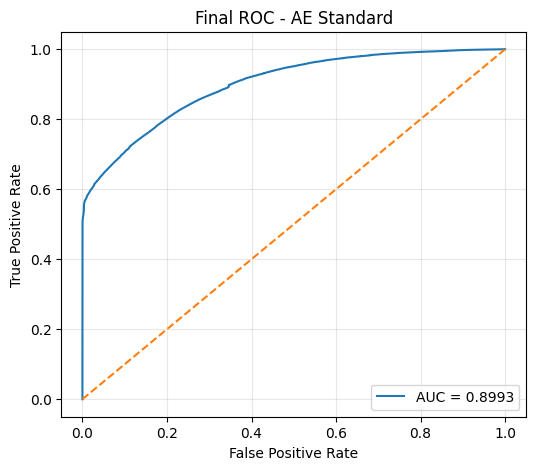

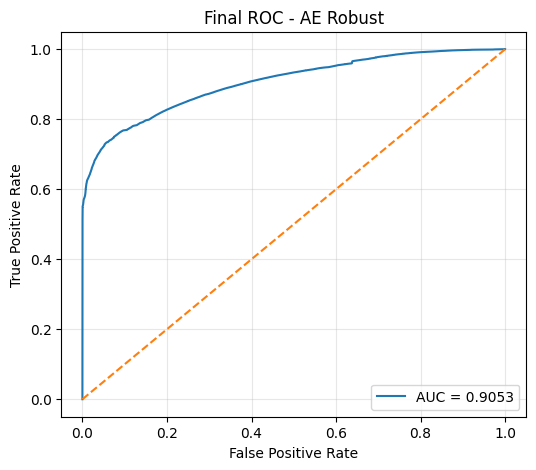

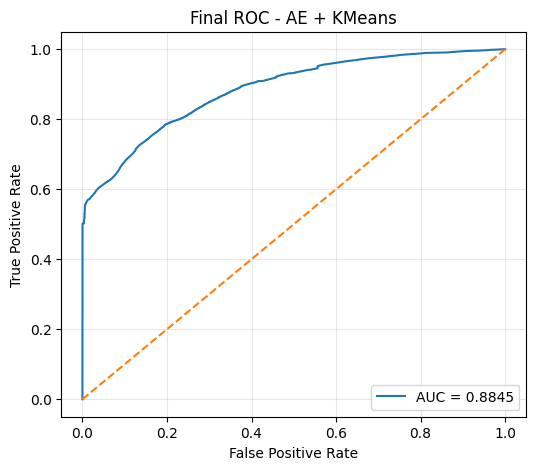

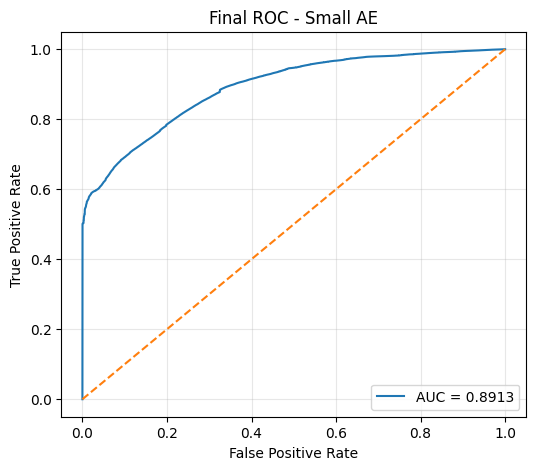

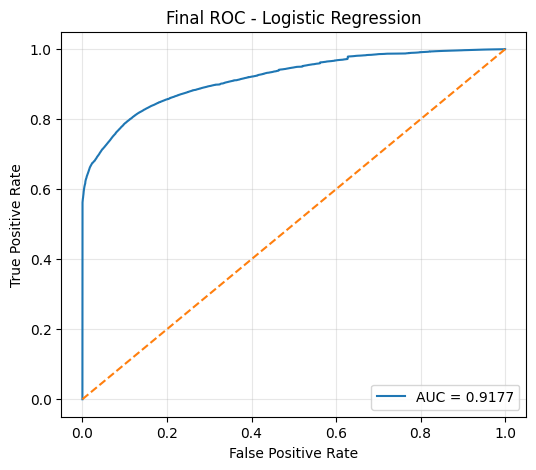

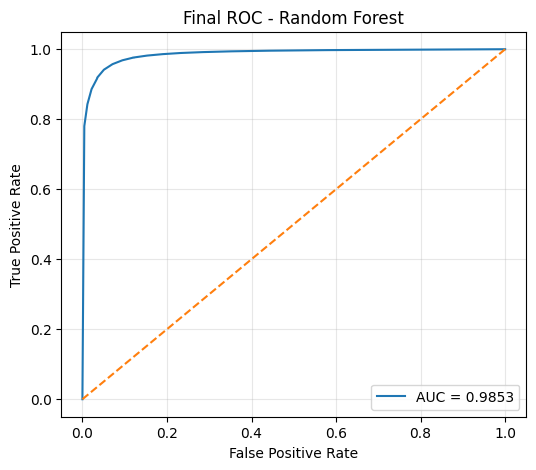

In [32]:
#Final ROC Curves
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_model_roc(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()


y_true_final = final_eval_df["label"].values

plot_model_roc(y_true_final, final_eval_df["ae_score"], "Final ROC - AE Standard")
plot_model_roc(y_true_final, final_eval_df["ae_robust_score"], "Final ROC - AE Robust")
plot_model_roc(y_true_final, final_eval_df["ae_km_score"], "Final ROC - AE + KMeans")
plot_model_roc(y_true_final, final_eval_df["small_ae_score"], "Final ROC - Small AE")
plot_model_roc(y_true_final, final_eval_df["lr_score"], "Final ROC - Logistic Regression")
plot_model_roc(y_true_final, final_eval_df["rf_score"], "Final ROC - Random Forest")

## Overall Metrics Report

Here is the table that helps comparing the Autoencoder-based IoT attack classifier to other baseline models.

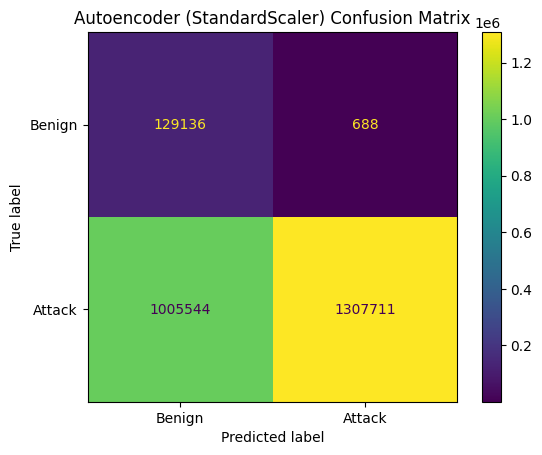

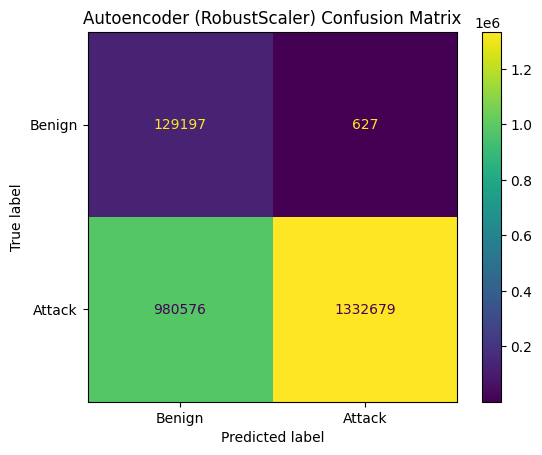

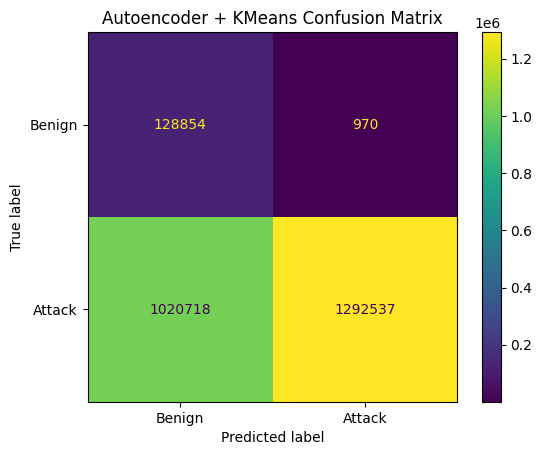

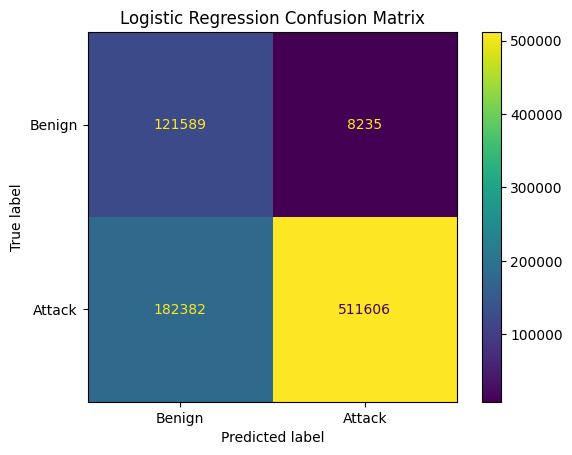

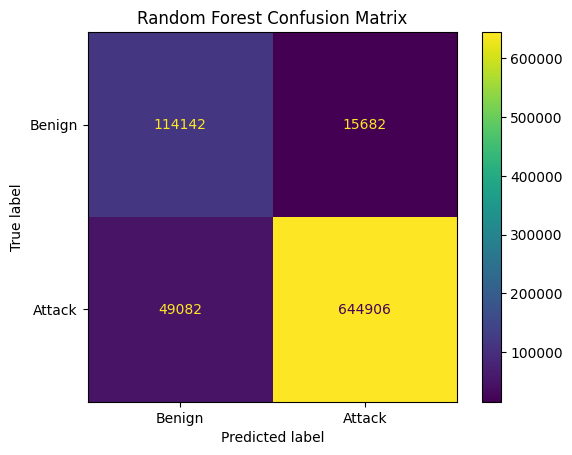

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def show_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Attack"]
    )

    disp.plot(values_format="d")
    plt.title(title)
    plt.show()

# --- Autoencoder (StandardScaler) ---
show_cm(
    y_test,
    ae_preds,
    "Autoencoder (StandardScaler) Confusion Matrix"
)

# --- Autoencoder (RobustScaler) ---
show_cm(
    y_test_robust,
    ae_robust_preds,
    "Autoencoder (RobustScaler) Confusion Matrix"
)

# --- AE + KMeans ---
show_cm(
    y_test,
    ae_km_preds,
    "Autoencoder + KMeans Confusion Matrix"
)

# --- Logistic Regression ---
show_cm(
    y_test_full,
    lr_preds,
    "Logistic Regression Confusion Matrix"
)

# --- Random Forest ---
show_cm(
    y_test_full,
    rf_15_preds,
    "Random Forest Confusion Matrix"
)

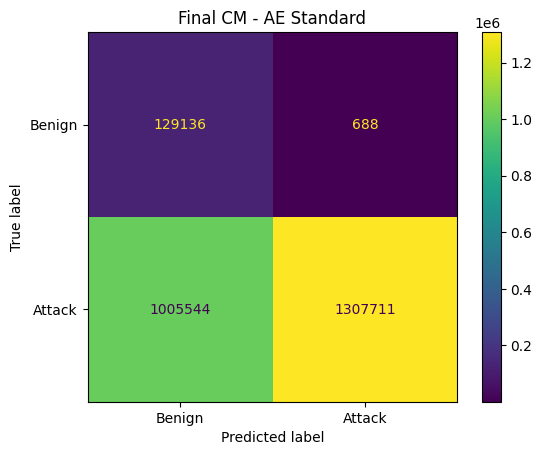

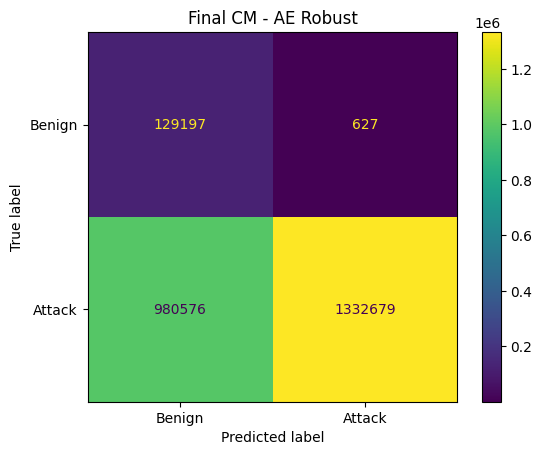

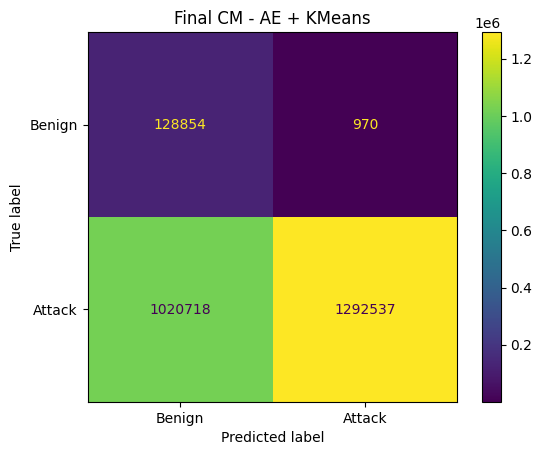

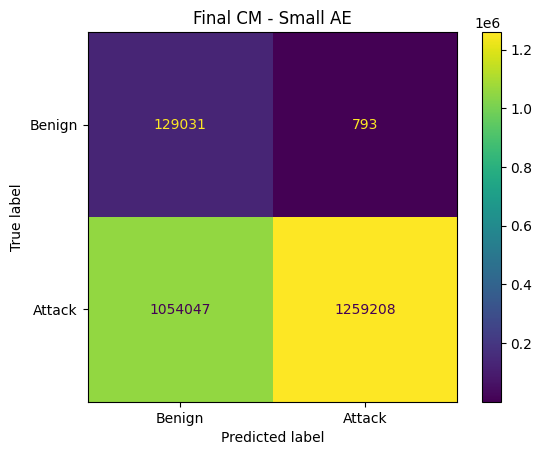

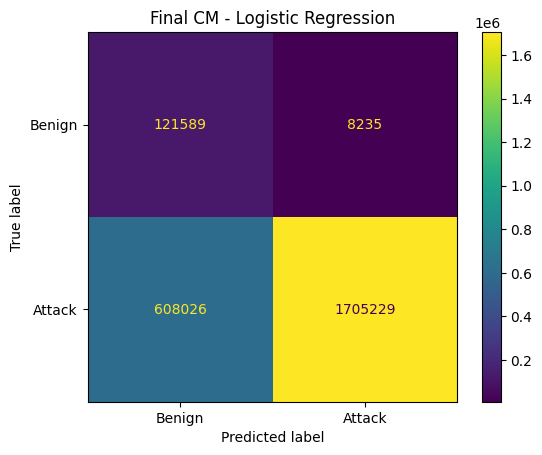

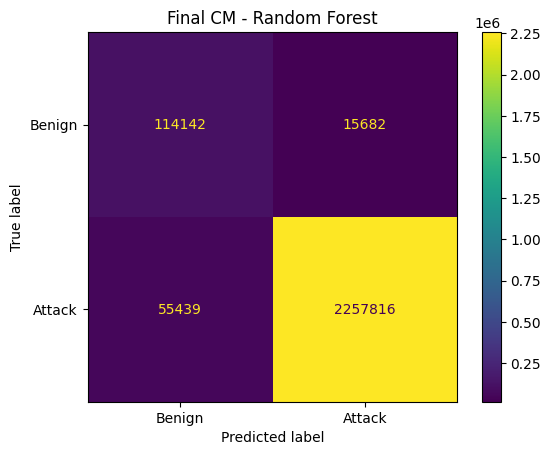

In [34]:
#Final Confusion Matrices
show_cm(final_eval_df["label"], final_eval_df["ae_pred"], "Final CM - AE Standard")
show_cm(final_eval_df["label"], final_eval_df["ae_robust_pred"], "Final CM - AE Robust")
show_cm(final_eval_df["label"], final_eval_df["ae_km_pred"], "Final CM - AE + KMeans")
show_cm(final_eval_df["label"], final_eval_df["small_ae_pred"], "Final CM - Small AE")
show_cm(final_eval_df["label"], final_eval_df["lr_pred"], "Final CM - Logistic Regression")
show_cm(final_eval_df["label"], final_eval_df["rf_pred"], "Final CM - Random Forest")

In [35]:
#Thresholding Logic to check if 0.5% FPR applied correctly
#Should be about 0.005
val_preds = (val_errors > threshold).astype(int)
val_fpr_check = val_preds.mean()
print("Validation-set FPR check (standard):", val_fpr_check)

val_preds_robust = (val_errors_robust > threshold_robust).astype(int)
val_fpr_check_robust = val_preds_robust.mean()
print("Validation-set FPR check (robust):", val_fpr_check_robust)

Validation-set FPR check (standard): 0.005000080542534513
Validation-set FPR check (robust): 0.005000080542534513


In [36]:
import time
import numpy as np

#latency evaluation
def measure_avg_latency(predict_fn, X, n_runs=5):
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        _ = predict_fn(X)
        end = time.perf_counter()
        times.append(end - start)
    avg_s = np.mean(times)
    ms_per_sample = avg_s / len(X) * 1000
    return avg_s, ms_per_sample

#subset test
X_test_small = X_test[:10000]
X_test_full_small = X_test_full[:10000]

ae_total_s, ae_ms_per_sample = measure_avg_latency(
    lambda x: ae.predict(x, verbose=0),
    X_test_small
)

lr_total_s, lr_ms_per_sample = measure_avg_latency(
    lambda x: logreg.predict(x),
    X_test_full_small
)

rf_total_s, rf_ms_per_sample = measure_avg_latency(
    lambda x: rf_15_model.predict(x),
    X_test_full_small
)

#AE + K means
ae_km_total_s, ae_km_ms_per_sample = measure_avg_latency(
    lambda x: kmeans.transform(encoder.predict(x, verbose=0)),
    X_test_small
)

print("--- Latency Evaluation ---")
print(f"Autoencoder (StandardScaler) Total Time: {ae_total_s:.4f}s, MS per sample: {ae_ms_per_sample:.4f}ms")
print(f"Logistic Regression Total Time: {lr_total_s:.4f}s, MS per sample: {lr_ms_per_sample:.4f}ms")
print(f"Random Forest Total Time: {rf_total_s:.4f}s, MS per sample: {rf_ms_per_sample:.4f}ms")
print(f"Autoencoder + KMeans Total Time: {ae_km_total_s:.4f}s, MS per sample: {ae_km_ms_per_sample:.4f}ms")
ae_robust_total_s, ae_robust_ms_per_sample = measure_avg_latency(
    lambda x: ae_robust.predict(x, verbose=0),
    X_test_robust[:10000]
)

print(f"Autoencoder (RobustScaler) Total Time: {ae_robust_total_s:.4f}s, MS per sample: {ae_robust_ms_per_sample:.4f}ms")


#F1 scores
from sklearn.metrics import f1_score, roc_auc_score

ae_f1 = f1_score(y_test, ae_preds)
ae_robust_f1 = f1_score(y_test_robust, ae_robust_preds)
ae_km_f1 = f1_score(y_test, ae_km_preds)
lr_f1 = f1_score(y_test_full, lr_preds)
rf_f1 = f1_score(y_test_full, rf_15_preds)

print("--- F1 Scores ---")
print(f"Autoencoder (StandardScaler) F1 Score: {ae_f1}")
print(f"Autoencoder (RobustScaler) F1 Score: {ae_robust_f1}")
print(f"Autoencoder + KMeans F1 Score: {ae_km_f1}")
print(f"Logistic Regression F1 Score: {lr_f1}")
print(f"Random Forest F1 Score: {rf_f1}")

#ROC-AUC Scores
ae_auc = roc_auc_score(y_test, ae_errors)
ae_robust_auc = roc_auc_score(y_test_robust, ae_robust_errors)
ae_km_auc = roc_auc_score(y_test, ae_km_distances)
small_ae_auc = roc_auc_score(y_test, small_ae_errors)
lr_auc = roc_auc_score(y_test_full, lr_preds)
rf_auc = roc_auc_score(y_test_full, rf_15_preds)

# Evaluate Small Autoencoder
tn_small_ae, fp_small_ae, fn_small_ae, tp_small_ae = confusion_matrix(y_test, small_ae_preds).ravel()
small_ae_recall = tp_small_ae / (tp_small_ae + fn_small_ae)
small_ae_fpr = fp_small_ae / (fp_small_ae + tn_small_ae)
small_ae_f1 = f1_score(y_test, small_ae_preds)
print("Small AE Recall @ 0.5% FPR:", small_ae_recall)
print("Small AE Actual FPR:", small_ae_fpr, "\n")
print("Small AE Classification Report: \n\n", classification_report(y_test, small_ae_preds))

# Measure latency for small autoencoder
small_ae_total_s, small_ae_ms_per_sample = measure_avg_latency(
    lambda x: small_ae.predict(x, verbose=0),
    X_test_small
)
print(f"Small Autoencoder Total Time: {small_ae_total_s:.4f}s, MS per sample: {small_ae_ms_per_sample:.4f}ms")

--- Latency Evaluation ---
Autoencoder (StandardScaler) Total Time: 0.7232s, MS per sample: 0.0723ms
Logistic Regression Total Time: 0.0013s, MS per sample: 0.0001ms
Random Forest Total Time: 0.1458s, MS per sample: 0.0146ms
Autoencoder + KMeans Total Time: 0.5891s, MS per sample: 0.0589ms
Autoencoder (RobustScaler) Total Time: 0.5699s, MS per sample: 0.0570ms
--- F1 Scores ---
Autoencoder (StandardScaler) F1 Score: 0.7221623048474537
Autoencoder (RobustScaler) F1 Score: 0.7309237388322861
Autoencoder + KMeans F1 Score: 0.7167298535362189
Logistic Regression F1 Score: 0.842962229440885
Random Forest F1 Score: 0.9521887291669128
Small AE Recall @ 0.5% FPR: 0.5443446572038102
Small AE Actual FPR: 0.006108269657382303 

Small AE Classification Report: 

               precision    recall  f1-score   support

           0       0.11      0.99      0.20    129824
           1       1.00      0.54      0.70   2313255

    accuracy                           0.57   2443079
   macro avg       0

In [37]:
import pickle

def get_model_size(model, name="Model"):
    serialized = pickle.dumps(model)
    size_bytes = len(serialized)
    size_kb = size_bytes / 1024
    return size_kb

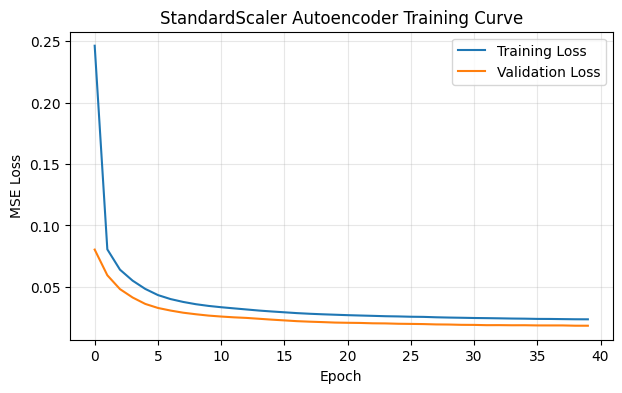

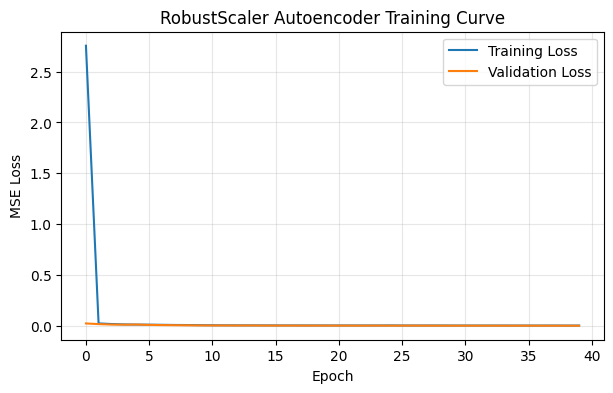

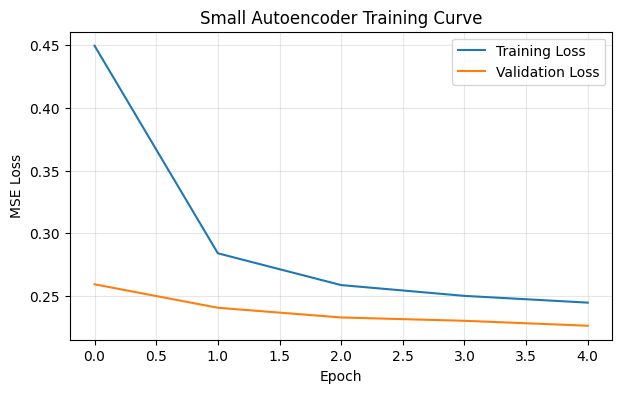

,Model,Size,Size (kB),Recall,FPR,F1,ROC-AUC Score,Latency (ms/sample),Lightweight?
0,AE (StandardScaler),3919 params,87.727539,0.565312,0.005299,0.722162,0.899258,0.072321,Yes
1,AE (RobustScaler),3919 params,87.749023,0.576106,0.004830,0.730924,0.905347,0.056992,Yes
2,AE + KMeans,3919 params + 64 centroid values,2571.051758,0.558752,0.007472,0.716730,0.884545,0.058909,Yes
3,Logistic Regression,40 params,1.012695,0.737197,0.063432,0.842962,0.836883,0.000127,Yes
4,Random Forest,"15 trees, 912297 nodes",438242.496094,0.929275,0.120794,0.952189,0.904241,0.014582,No
5,AE (Small),1418 params,48.943359,0.544345,0.006108,0.704796,0.891261,0.085923,Yes


In [38]:
#Training curve plots
import matplotlib.pyplot as plt

def plot_training_curve(history, title):
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Standard AE
plot_training_curve(history, 'StandardScaler Autoencoder Training Curve')

# Robust AE
plot_training_curve(history_robust, 'RobustScaler Autoencoder Training Curve')

# Plot training curve for Small Autoencoder
plot_training_curve(history_small_ae, 'Small Autoencoder Training Curve')

#summary table
import pandas as pd

summary_df = pd.DataFrame([
    {
        "Model": "AE (StandardScaler)",
        "Size": "3919 params",
        "Size (kB)": get_model_size(ae),
        "Recall": ae_recall,
        "FPR": ae_fpr,
        "F1": ae_f1,
        "ROC-AUC Score": ae_auc,
        "Latency (ms/sample)": ae_ms_per_sample,
        "Lightweight?": "Yes"
    },
    {
        "Model": "AE (RobustScaler)",
        "Size": "3919 params",
        "Size (kB)": get_model_size(ae_robust),
        "Recall": ae_robust_recall,
        "FPR": ae_robust_fpr,
        "F1": ae_robust_f1,
        "ROC-AUC Score": ae_robust_auc,
        "Latency (ms/sample)": ae_robust_ms_per_sample,
        "Lightweight?": "Yes"
    },
    {
        "Model": "AE + KMeans",
        "Size": "3919 params + 64 centroid values",
        "Size (kB)": get_model_size(kmeans),
        "Recall": ae_k_recall,
        "FPR": ae_k_fpr,
        "F1": ae_km_f1,
        "ROC-AUC Score": ae_km_auc,
        "Latency (ms/sample)": ae_km_ms_per_sample,
        "Lightweight?": "Yes"
    },
    {
        "Model": "Logistic Regression",
        "Size": "40 params",
        "Size (kB)": get_model_size(logreg),
        "Recall": lr_recall,
        "FPR": lr_fpr,
        "F1": lr_f1,
        "ROC-AUC Score": lr_auc,
        "Latency (ms/sample)": lr_ms_per_sample,
        "Lightweight?": "Yes"
    },
    {
        "Model": "Random Forest",
        "Size": "15 trees, 912297 nodes",
        "Size (kB)": get_model_size(rf_15_model),
        "Recall": rf_recall,
        "FPR": rf_fpr,
        "F1": rf_f1,
        "ROC-AUC Score": rf_auc,
        "Latency (ms/sample)": rf_ms_per_sample,
        "Lightweight?": "No"
    },
    {
      "Model": "AE (Small)",
      "Size": f"{count_parameters(small_ae)} params",
      "Size (kB)": get_model_size(small_ae),
      "Recall": small_ae_recall,
      "FPR": small_ae_fpr,
      "F1": small_ae_f1,
      "ROC-AUC Score": small_ae_auc,
      "Latency (ms/sample)": small_ae_ms_per_sample,
      "Lightweight?": "Yes"
    }
])
display(summary_df)